(61878, 95)
(144368, 94)


,id,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,feat_9,...,feat_85,feat_86,feat_87,feat_88,feat_89,feat_90,feat_91,feat_92,feat_93,target
0,1,1,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,Class_1
1,2,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,Class_1
2,3,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,Class_1
3,4,1,0,0,1,6,1,5,0,0,...,0,1,2,0,0,0,0,0,0,Class_1
4,5,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,1,0,0,0,Class_1


,id,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,feat_9,...,feat_84,feat_85,feat_86,feat_87,feat_88,feat_89,feat_90,feat_91,feat_92,feat_93
0,1,0,0,0,0,0,0,0,0,0,...,0,0,11,1,20,0,0,0,0,0
1,2,2,2,14,16,0,0,0,0,0,...,0,0,0,0,0,4,0,0,2,0
2,3,0,1,12,1,0,0,0,0,0,...,0,0,0,0,2,0,0,0,0,1
3,4,0,0,0,1,0,0,0,0,0,...,0,3,1,0,0,0,0,0,0,0
4,5,1,0,0,1,0,0,1,2,0,...,0,0,0,0,0,0,0,9,0,0


<class 'pandas.DataFrame'>
RangeIndex: 61878 entries, 0 to 61877
Data columns (total 95 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   id       61878 non-null  int64
 1   feat_1   61878 non-null  int64
 2   feat_2   61878 non-null  int64
 3   feat_3   61878 non-null  int64
 4   feat_4   61878 non-null  int64
 5   feat_5   61878 non-null  int64
 6   feat_6   61878 non-null  int64
 7   feat_7   61878 non-null  int64
 8   feat_8   61878 non-null  int64
 9   feat_9   61878 non-null  int64
 10  feat_10  61878 non-null  int64
 11  feat_11  61878 non-null  int64
 12  feat_12  61878 non-null  int64
 13  feat_13  61878 non-null  int64
 14  feat_14  61878 non-null  int64
 15  feat_15  61878 non-null  int64
 16  feat_16  61878 non-null  int64
 17  feat_17  61878 non-null  int64
 18  feat_18  61878 non-null  int64
 19  feat_19  61878 non-null  int64
 20  feat_20  61878 non-null  int64
 21  feat_21  61878 non-null  int64
 22  feat_22  61878 non-null  int64
 2

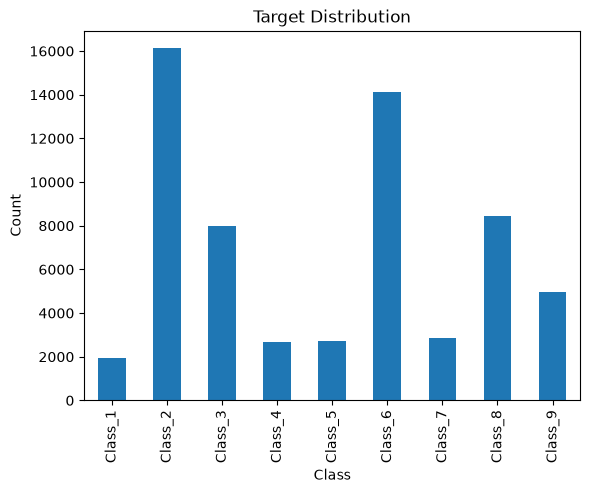

(61878, 93)
   feat_1  feat_2  feat_3  feat_4  feat_5  feat_6  feat_7  feat_8  feat_9  \
0       1       0       0       0       0       0       0       0       0   
1       0       0       0       0       0       0       0       1       0   
2       0       0       0       0       0       0       0       1       0   
3       1       0       0       1       6       1       5       0       0   
4       0       0       0       0       0       0       0       0       0   

   feat_10  ...  feat_84  feat_85  feat_86  feat_87  feat_88  feat_89  \
0        0  ...        0        1        0        0        0        0   
1        0  ...        0        0        0        0        0        0   
2        0  ...        0        0        0        0        0        0   
3        1  ...       22        0        1        2        0        0   
4        0  ...        0        1        0        0        0        0   

   feat_90  feat_91  feat_92  feat_93  
0        0        0        0        0  
1     

In [21]:
import pandas as pd

train_data = pd.read_csv('train.csv')
test_data = pd.read_csv('test.csv')

# 数据分析
print(train_data.shape)
print(test_data.shape)

display(train_data.head())
display(test_data.head())

print(train_data.info())
print(train_data['target'].value_counts())
import matplotlib.pyplot as plt

train_data['target'].value_counts().sort_index().plot(kind='bar')

plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Target Distribution')
plt.show()

# 数据预处理
x= train_data.drop(columns=['id','target'])
y= train_data['target']

print(x.shape)
print(x.head())

print(y.shape)
print(y.head())

# 将target变成整数，便于后面分类
y = y.str.replace('Class_','').astype(int) -1
print(y.head())
print(y.dtype)


In [43]:
import torch
# 划分数据集和验证集
from sklearn.model_selection import train_test_split

X_train,X_valid,y_train,y_valid = train_test_split(
    x,
    y,
    test_size = 0.2,
    random_state=42,
    stratify=y
)

from sklearn.preprocessing import StandardScaler

# 对特征进行标准化
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)
# 将 x 转化成tensor
X_train = torch.tensor(X_train,dtype=torch.float32)
X_valid = torch.tensor(X_valid,dtype=torch.float32)

# 将 y 转化成tensor(这里y不需要参与浮点运算，所以设置为长整型)
y_train = torch.tensor(y_train.to_numpy(),dtype=torch.long)
y_valid = torch.tensor(y_valid.to_numpy(),dtype=torch.long)

print(X_train.shape)
print(X_train.dtype)
print(y_train.shape)
print(y_train.dtype)



torch.Size([49502, 93])
torch.float32
torch.Size([49502])
torch.int64


In [50]:
# 开始建立Dataset
from torch.utils.data import TensorDataset,DataLoader

# 因为这里x,y都是tensor了，所以可以直接用Dataset转
train_dataset = TensorDataset(X_train,y_train)
valid_dataset = TensorDataset(X_valid,y_valid)

# 创建DataLoader
batch_size = 64
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)
valid_loader = DataLoader(
    valid_dataset,
    batch_size=batch_size,
    shuffle=False
)

class OttoModel(torch.nn.Module):
    def __init__(self):
        super().__init__()

        self.model =torch.nn.Sequential(
            torch.nn.Linear(93,256),
            torch.nn.ReLU(),

            torch.nn.Linear(256,128),
            torch.nn.ReLU(),

            torch.nn.Linear(128,64),
            torch.nn.ReLU(),

            torch.nn.Linear(64,9)
        )
    def forward(self,x):
        return self.model(x)

model = OttoModel()

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),lr=0.01)

# 因为这个是多分类的Log Loss 所以我们不仅要看loss，更要看Accuracy
# 用来记录每一轮数据
train_losses = []
valid_losses = []

train_accuracies = []
valid_accuracies = []
# 记录目前最好的验证集 loss
best_valid_loss = float('inf')

for epoch in range(50):
    # 开始训练
    model.train()

    train_loss=0.0
    train_correct = 0.0
    train_total=0.0

    for x_batch,y_batch in train_loader:

        output = model(x_batch)

        loss = criterion(output,y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step

        train_loss+= loss.item()* x_batch.size(0)

        # 找出预测类别
        pred =torch.argmax(output,dim=1)

        # 统计预测正确数量
        train_correct+=(pred==y_batch).sum().item()

        # 统计总样本数量
        train_total += y_batch.size(0)

    train_loss /=train_total
    train_acc =train_correct/train_total

    # 开始验证
    model.eval()

    valid_loss=0.0
    valid_correct=0.0
    valid_total=0.0

    for x_batch,y_batch in valid_loader:

        output = model(x_batch)
        loss = criterion(output,y_batch)
        optimizer.zero_grad()
        loss.backword()
        optimizer.step()

        valid_loss+=loss.item() * y_batch.size(0)

        pre = torch.agmax(output,dim=1)

        valid_correct +=(pred==y_batch).sum().item()

        valid_total += y_batch.size(0)
        

OttoModel(
  (model): Sequential(
    (0): Linear(in_features=93, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=9, bias=True)
  )
)
